# Transfer Learning
Transfer learning jest jedną z kluczowych koncepcji pracy z sieciami neuronowymi, najczęściej wykorzystywanym przy trenowaniu modeli pod najróżniejsze rozwiązania (najwięcej przykładów pochodzi z dziedziny rozpoznawania obrazów, przy czym nie jest to jedyne możliwe zastosowanie).

Z puntku widzenia przygotowania działającego modelu nie zawsze jest sens trenować model od zera. Często też nie mamy wystarczająco danych by korzystając z nich wytrenować dobrze działające rozwiązanie. W takich przypadkach trasnfer learning umożliwia przygotowanie dobrego i działającego modelu o wiele szybciej i/lub przy ograniczonych danych.

 W tym wypadku wykorzystamy sieć ResNet50 do rozpoznawania obiektów na obrazach. W normalnych warunkach wytrenowanie podobnej sieci wymaga dużej liczby oznacznych obrazów i jest bardzo czasochłonne, zarówno pod kątem przygotowania danych jak i samego trenowania sieci. Korzytając z transfer learning możemy załadować wagi istniejącej sieci i zacząć praktycznie od razu wykrywać obiekty na obrazach. 

Zaczynamy oczywiście od serii importów. Obrazki testowe umieszczone w folderze Images pochodzą z jednego ze zbiorów na kaggle.com (https://www.kaggle.com/datasets/kkhandekar/object-detection-sample-images?select=7.jpg)

In [10]:
import torch
import torchvision
from PIL import Image
from torchvision.transforms import functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tkinter import Tk
from tkinter.filedialog import askopenfilename

# Images in the Image folder from: https://www.kaggle.com/datasets/kkhandekar/object-detection-sample-images?select=7.jpg

Mając wszyzstkie potrzebne biblioteki, możemy od razu załadować model. ResNet50 jest jednym z pretrenowanych modeli dostępnych w ramach biblioteki Pytorch, można więc załadować go bezpośrednio. W kolejnym kroku przełączamy model na tryb ewaluacji, jako że nie mamy dość obrazów do dalszego trenowania i będziemy chcieli od razu przeprowadzić detekcję.

In [11]:
# Load a pre-trained Faster R-CNN model
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=torchvision.models.ResNet50_Weights)
model.eval()  # Set the model to evaluation mode

d:\Files\__Zajecia\05_SGGW_Podyp\2025_2026_Zima_UczenieMaszynowe\PythonFolder_ML\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

Jako że będziemy ładować obrazki, przyda nam się metoda do tego.

In [12]:
# Function to load an image and convert it to a tensor
def load_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = F.to_tensor(image)
    return image

Oraz kolejną metodę realizującą oznaczanie obiektów na wskazanym obrazie.

W ramach tej funkcji ustawiamy device na kartę graficzną, jeżeli jest dostępna, lub CPU w innym przypadku, plus przestawimy model na wybrane urządzenie. Przenosimy na nie również wskazany obrazek, jako że data i model muszą znajdować się na tym samym urządzeniu. Później przepuszczamy nasz obrazek przez pretrenowany model. 

In [13]:
# Function to perform object detection
def detect_objects(model, image, threshold=0.5):
    # Move the image to the same device as the model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    image = image.to(device)

    # Perform inference
    with torch.no_grad():
        outputs = model([image])

    # Filter out detections with a score below the threshold
    detections = outputs[0]
    scores = detections['scores']
    keep = scores >= threshold
    filtered_detections = {k: v[keep].cpu() for k, v in detections.items()}

    return filtered_detections

W następnej kolejności chcemy narysować ramki dookoła wykrytych obiektów na naszymo obrazie i pokazać obraz. Do tego również najlepiej zrobić osobną metodę.

In [14]:
# Function to plot the image with detected bounding boxes
def plot_detections(image, detections):
    # Convert the tensor image to a numpy array and transpose it to [H, W, C] format
    image = image.permute(1, 2, 0).numpy()
    # Create a figure and axis
    fig, ax = plt.subplots(1, figsize=(12, 9))
    # Display the image
    ax.imshow(image)
    # Plot each bounding box
    for box in detections['boxes']:
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        rect = patches.Rectangle(
            (x1, y1), width, height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
    # Set plot title and show plot
    ax.set_title('Object Detections')
    plt.show()

Trochę interaktywności - wczytywanie obrazka przez użytkownika z wykorzystaniem biblioteki Tkinter - służącej do tworzenia interfejsu użytkownika. Pierwsza linia usuwa główne okno, jako że nie potrzebujemy pełnego interfejsu, a tylko filedialog. Następnie ładujemy wskazany przez użytkownika obrazek, w celu oznaczenia obiektów na nim. 

In [15]:
# Load an image
Tk().withdraw()
image_path = askopenfilename()
image = load_image(image_path)

Po załadowaniu obrazka zostaje nam już tylko detekcja i narysowanie oraz wyświetlenie obrazka z ramkami pokazującymi położenie wykrytych obiektów. 

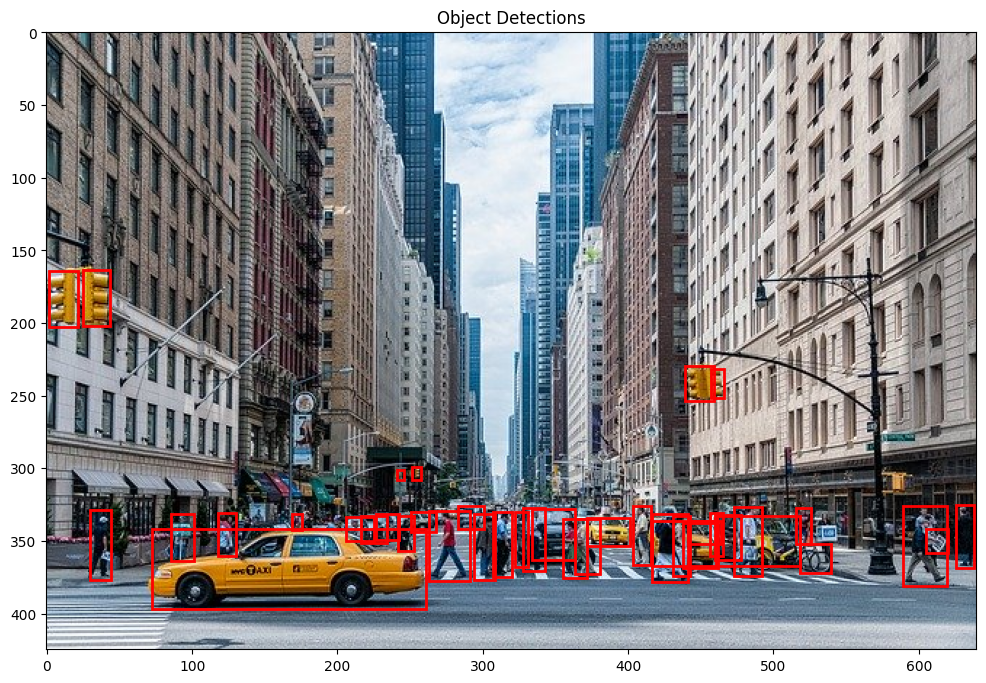

In [9]:
# Perform object detection
detections = detect_objects(model, image, threshold=0.5)
# Plot the image with detections
plot_detections(image, detections)

Zakładając, że zbiór z 10-cioma obrazkami z kaggle jest wszystkim co mamy, łatwo domyślić się, że nijak nie bylibyśmy w stanie z jego pomocą wytrenować jakkolwiek rozsądnego modelu do detekcji obrazu. Korzystanie z pretrenowanego modelu nie tylko nie wymaga dodatkowego treningu, ale pozwala nam od razu wykorzystać go do oznaczania obiektów. Oczywiście jakość działania w tym wypadku zależy całkowicie od oryginalnego modelu. 